In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs("../reports/charts", exist_ok=True)
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
np.random.seed(42)

schemes_40 = {
    125497: ("HDFC Top 100 Direct",          "HDFC AMC",    "Large Cap"),
    119551: ("SBI Bluechip Direct",           "SBI MF",      "Large Cap"),
    120503: ("ICICI Prudential Bluechip",     "ICICI MF",    "Large Cap"),
    118632: ("Nippon India Large Cap",        "Nippon MF",   "Large Cap"),
    119092: ("Axis Bluechip Direct",          "Axis MF",     "Large Cap"),
    120841: ("Kotak Bluechip Direct",         "Kotak MF",    "Large Cap"),
    120465: ("Mirae Asset Large Cap",         "Mirae MF",    "Large Cap"),
    119597: ("DSP Top 100",                   "DSP MF",      "Large Cap"),
    120716: ("Franklin India Bluechip",       "Franklin MF", "Large Cap"),
    119820: ("Tata Large Cap",                "Tata MF",     "Large Cap"),
    120200: ("HDFC Midcap Opportunities",     "HDFC AMC",    "Mid Cap"),
    119598: ("SBI Magnum Midcap",             "SBI MF",      "Mid Cap"),
    120504: ("ICICI Prudential Midcap",       "ICICI MF",    "Mid Cap"),
    118633: ("Nippon India Growth",           "Nippon MF",   "Mid Cap"),
    119093: ("Axis Midcap Direct",            "Axis MF",     "Mid Cap"),
    120842: ("Kotak Emerging Equity",         "Kotak MF",    "Mid Cap"),
    120466: ("Mirae Asset Midcap",            "Mirae MF",    "Mid Cap"),
    119599: ("DSP Midcap",                    "DSP MF",      "Mid Cap"),
    120717: ("Franklin India Prima",          "Franklin MF", "Mid Cap"),
    119821: ("Tata Midcap Growth",            "Tata MF",     "Mid Cap"),
    120201: ("HDFC Small Cap",                "HDFC AMC",    "Small Cap"),
    119600: ("SBI Small Cap",                 "SBI MF",      "Small Cap"),
    120505: ("ICICI Prudential Smallcap",     "ICICI MF",    "Small Cap"),
    118634: ("Nippon India Small Cap",        "Nippon MF",   "Small Cap"),
    119094: ("Axis Small Cap",                "Axis MF",     "Small Cap"),
    120843: ("Kotak Small Cap",               "Kotak MF",    "Small Cap"),
    120467: ("Mirae Asset Small Cap",         "Mirae MF",    "Small Cap"),
    119601: ("DSP Small Cap",                 "DSP MF",      "Small Cap"),
    120718: ("Franklin India Smaller Cos",    "Franklin MF", "Small Cap"),
    119822: ("Tata Small Cap",                "Tata MF",     "Small Cap"),
    120202: ("HDFC Balanced Advantage",       "HDFC AMC",    "Hybrid"),
    119602: ("SBI Equity Hybrid",             "SBI MF",      "Hybrid"),
    120506: ("ICICI Prudential Balanced",     "ICICI MF",    "Hybrid"),
    118635: ("Nippon India Balanced",         "Nippon MF",   "Hybrid"),
    119095: ("Axis Balanced Advantage",       "Axis MF",     "Hybrid"),
    120844: ("Kotak Balanced Advantage",      "Kotak MF",    "Hybrid"),
    120468: ("Mirae Asset Hybrid Equity",     "Mirae MF",    "Hybrid"),
    119603: ("DSP Equity & Bond",             "DSP MF",      "Hybrid"),
    120719: ("Franklin India Balanced",       "Franklin MF", "Hybrid"),
    119823: ("Tata Balanced Advantage",       "Tata MF",     "Hybrid"),
}

dates = pd.date_range("2022-01-01", "2026-05-31", freq="B")
nav_rows = []
for code, (name, house, category) in schemes_40.items():
    nav = np.random.uniform(80, 200)
    for date in dates:
        if date.year == 2023:
            drift = 0.0006
        elif date.year == 2024 and date.month in [3, 4, 10, 11]:
            drift = -0.0004
        else:
            drift = 0.0003
        nav = nav * (1 + np.random.normal(drift, 0.012))
        nav_rows.append({
            "amfi_code": code,
            "scheme_name": name,
            "fund_house": house,
            "category": category,
            "date": date,
            "nav": round(max(nav, 1), 4)
        })

df_nav = pd.DataFrame(nav_rows)
df_nav.to_csv("../data/processed/nav_40schemes.csv", index=False)
print(f"✅ NAV data: {df_nav.shape} — {df_nav['amfi_code'].nunique()} schemes")

✅ NAV data: (46000, 6) — 40 schemes


In [3]:
fund_houses = ["HDFC AMC", "SBI MF", "ICICI MF", "Nippon MF",
               "Axis MF", "Kotak MF", "Mirae MF", "DSP MF",
               "Franklin MF", "Tata MF"]

aum_base = {
    "HDFC AMC": 450000, "SBI MF": 800000, "ICICI MF": 600000,
    "Nippon MF": 350000, "Axis MF": 280000, "Kotak MF": 320000,
    "Mirae MF": 180000, "DSP MF": 150000, "Franklin MF": 120000,
    "Tata MF": 130000
}

aum_rows = []
for house in fund_houses:
    base = aum_base[house]
    for year in range(2022, 2026):
        growth = 1 + (year - 2022) * np.random.uniform(0.12, 0.20)
        aum_rows.append({
            "fund_house": house,
            "year": year,
            "aum_crores": round(base * growth, 0)
        })
df_aum = pd.DataFrame(aum_rows)
df_aum.to_csv("../data/processed/aum_by_fundhouse.csv", index=False)
print(f"✅ AUM data: {df_aum.shape}")

sip_dates = pd.date_range("2022-01-01", "2025-12-31", freq="MS")
sip_base = 12000
sip_rows = []
for date in sip_dates:
    months_elapsed = (date.year - 2022) * 12 + date.month
    sip_amount = sip_base + months_elapsed * 450 + np.random.normal(0, 300)
    if date.year == 2025 and date.month == 12:
        sip_amount = 31002
    sip_rows.append({
        "date": date,
        "month": date.strftime("%b %Y"),
        "sip_inflow_cr": round(sip_amount, 2)
    })
df_sip = pd.DataFrame(sip_rows)
df_sip.to_csv("../data/processed/sip_monthly.csv", index=False)
print(f"✅ SIP data: {df_sip.shape}")

n = 10000
age_groups = ["18-25", "26-35", "36-45", "46-55", "55+"]
age_weights = [0.15, 0.35, 0.28, 0.14, 0.08]
states = ["Maharashtra", "Delhi", "Karnataka", "Tamil Nadu",
          "West Bengal", "Gujarat", "Rajasthan", "UP", "Telangana", "Punjab"]
state_weights = [0.20, 0.18, 0.14, 0.10, 0.09, 0.08, 0.07, 0.06, 0.05, 0.03]

df_demo = pd.DataFrame({
    "investor_id":  range(1, n+1),
    "age_group":    np.random.choice(age_groups, n, p=age_weights),
    "gender":       np.random.choice(["Male", "Female", "Other"], n, p=[0.62, 0.37, 0.01]),
    "state":        np.random.choice(states, n, p=state_weights),
    "city_tier":    np.random.choice(["T30", "B30"], n, p=[0.65, 0.35]),
    "sip_amount":   np.random.choice([500,1000,2000,5000,10000,25000], n,
                                      p=[0.10,0.25,0.30,0.20,0.10,0.05])
})
df_demo.to_csv("../data/processed/investor_demographics.csv", index=False)
print(f"✅ Demographics data: {df_demo.shape}")

folio_dates = pd.date_range("2022-01-01", "2025-12-31", freq="MS")
folio_start = 13.26
folio_end   = 26.12
folio_vals  = np.linspace(folio_start, folio_end, len(folio_dates))
folio_vals += np.random.normal(0, 0.1, len(folio_dates))
df_folio = pd.DataFrame({"date": folio_dates, "folio_count_cr": folio_vals.round(2)})
df_folio.to_csv("../data/processed/folio_count.csv", index=False)
print(f"✅ Folio count data: {df_folio.shape}")

categories = ["Large Cap","Mid Cap","Small Cap","Hybrid","ELSS","Debt","Index","Flexi Cap"]
months_list = pd.date_range("2022-01-01", "2025-12-31", freq="MS")
inflow_rows = []
for date in months_list:
    for cat in categories:
        inflow_rows.append({
            "month": date.strftime("%b %Y"),
            "category": cat,
            "net_inflow_cr": round(np.random.uniform(-2000, 8000), 2)
        })
df_inflow = pd.DataFrame(inflow_rows)
df_inflow.to_csv("../data/processed/category_inflow.csv", index=False)
print(f"✅ Category inflow data: {df_inflow.shape}")

sectors = ["Financial Services","IT","Healthcare","Energy","Consumer Goods",
           "Automobile","Metals","Realty","Telecom","Infrastructure"]
sector_weights = [0.32, 0.18, 0.10, 0.09, 0.08, 0.07, 0.06, 0.04, 0.03, 0.03]
df_sector = pd.DataFrame({"sector": sectors, "weight_pct": [w*100 for w in sector_weights]})
df_sector.to_csv("../data/processed/sector_allocation.csv", index=False)
print(f"✅ Sector allocation data: {df_sector.shape}")

print("\n✅ All datasets generated!")

✅ AUM data: (40, 3)
✅ SIP data: (48, 3)
✅ Demographics data: (10000, 6)
✅ Folio count data: (48, 2)
✅ Category inflow data: (384, 3)
✅ Sector allocation data: (10, 2)

✅ All datasets generated!


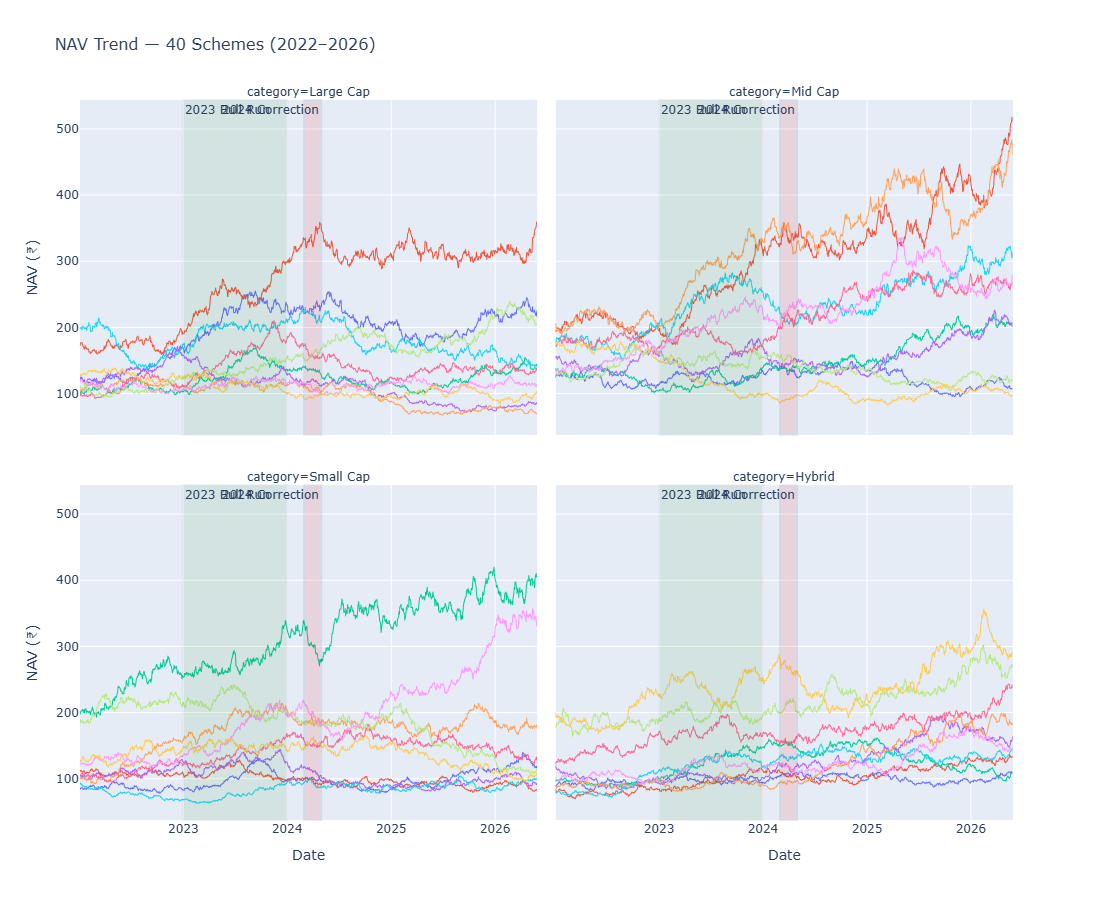

Chart 1 saved!


In [4]:
fig = px.line(
    df_nav,
    x="date", y="nav",
    color="scheme_name",
    facet_col="category",
    facet_col_wrap=2,
    title="NAV Trend — 40 Schemes (2022–2026)",
    labels={"nav": "NAV (₹)", "date": "Date"},
    height=900
)

fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.08,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-03-01", x1="2024-04-30",
    fillcolor="red", opacity=0.10,
    annotation_text="2024 Correction",
    annotation_position="top right"
)

fig.update_traces(line=dict(width=1))
fig.update_layout(showlegend=False, title_font_size=16)
fig.write_html("../reports/charts/01_nav_trend.html")
fig.show()
print("Chart 1 saved!")

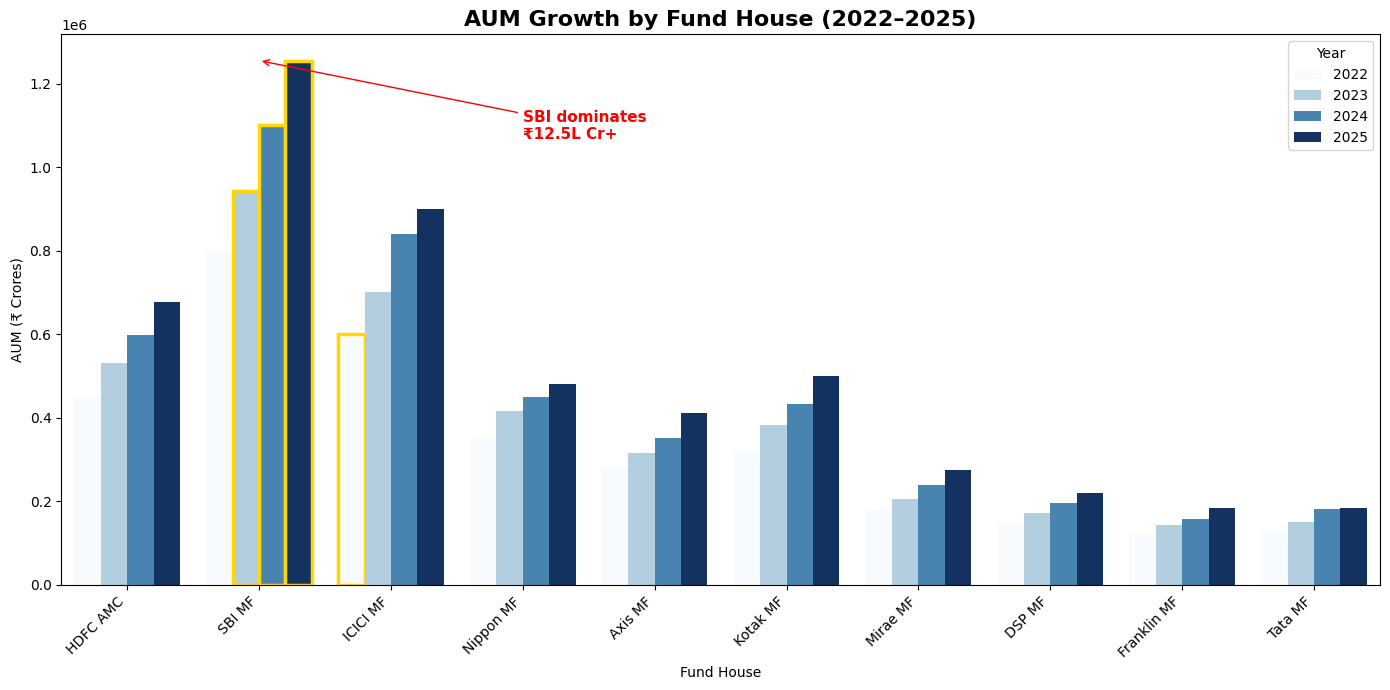

Chart 2 saved!


In [5]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_aum,
    x="fund_house", y="aum_crores",
    hue="year", palette="Blues"
)

for bar in ax.patches:
    if bar.get_x() > 0.6 and bar.get_x() < 1.6:
        bar.set_edgecolor("gold")
        bar.set_linewidth(2.5)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16, fontweight="bold")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crores)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.annotate("SBI dominates\n₹12.5L Cr+",
             xy=(1, df_aum[df_aum['fund_house']=='SBI MF']['aum_crores'].max()),
             xytext=(3, df_aum['aum_crores'].max() * 0.85),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=11, color="red", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/charts/02_aum_growth.png", dpi=150)
plt.show()
print("Chart 2 saved!")

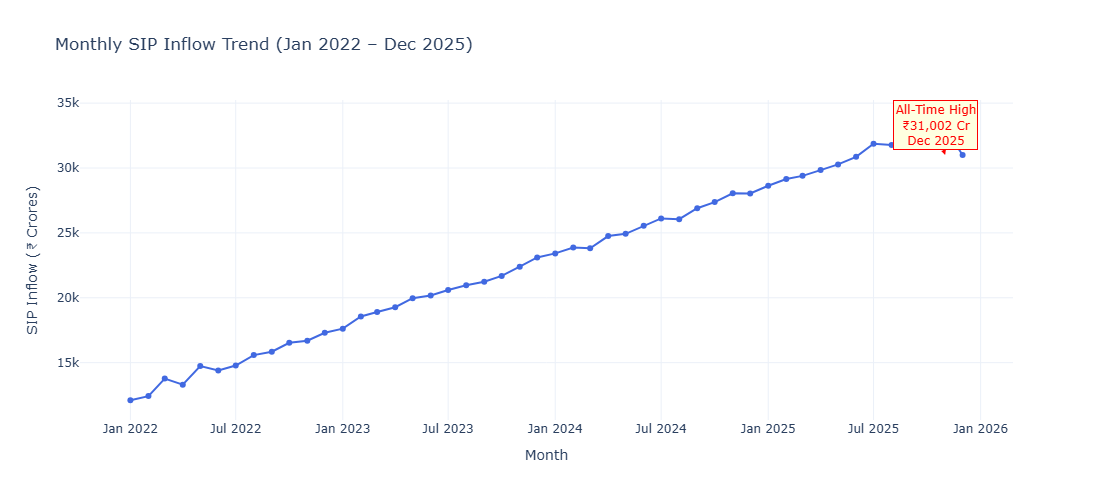

Chart 3 saved!


In [6]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_sip['date'], y=df_sip['sip_inflow_cr'],
    mode='lines+markers',
    line=dict(color='royalblue', width=2),
    name='SIP Inflow'
))

ath_date = df_sip[df_sip['sip_inflow_cr'] == df_sip['sip_inflow_cr'].max()]['date'].values[0]
fig.add_annotation(
    x=ath_date,
    y=31002,
    text="All-Time High<br>₹31,002 Cr<br>Dec 2025",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    font=dict(color="red", size=12),
    bgcolor="lightyellow",
    bordercolor="red"
)

fig.update_layout(
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crores)",
    height=500,
    template="plotly_white"
)
fig.write_html("../reports/charts/03_sip_trend.html")
fig.show()
print("Chart 3 saved!")

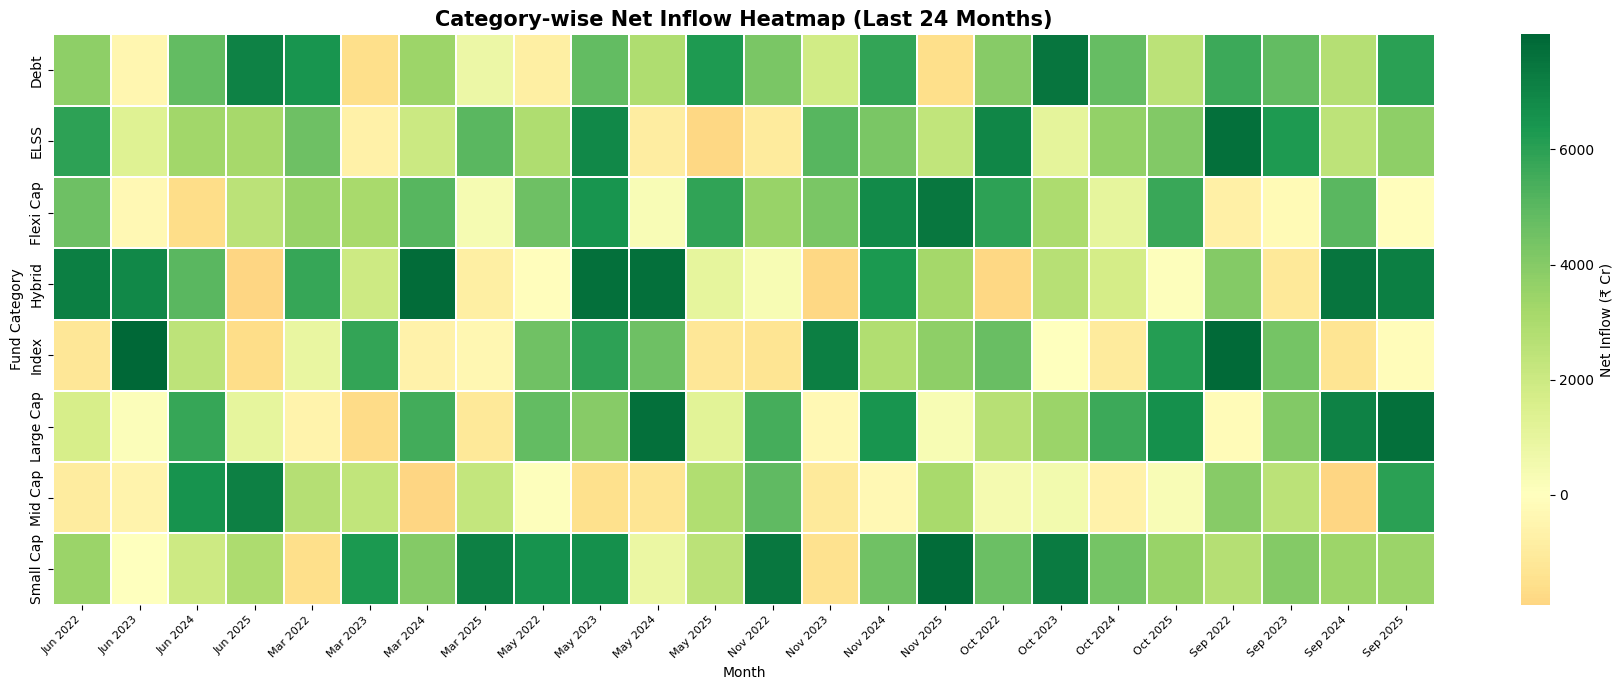

Chart 4 saved!


In [7]:
pivot = df_inflow.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_cr"
)
pivot = pivot.iloc[:, -24:]

plt.figure(figsize=(18, 7))
sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0,
    linewidths=0.3,
    fmt=".0f",
    annot=False,
    cbar_kws={"label": "Net Inflow (₹ Cr)"}
)
plt.title("Category-wise Net Inflow Heatmap (Last 24 Months)", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/04_category_heatmap.png", dpi=150)
plt.show()
print("Chart 4 saved!")

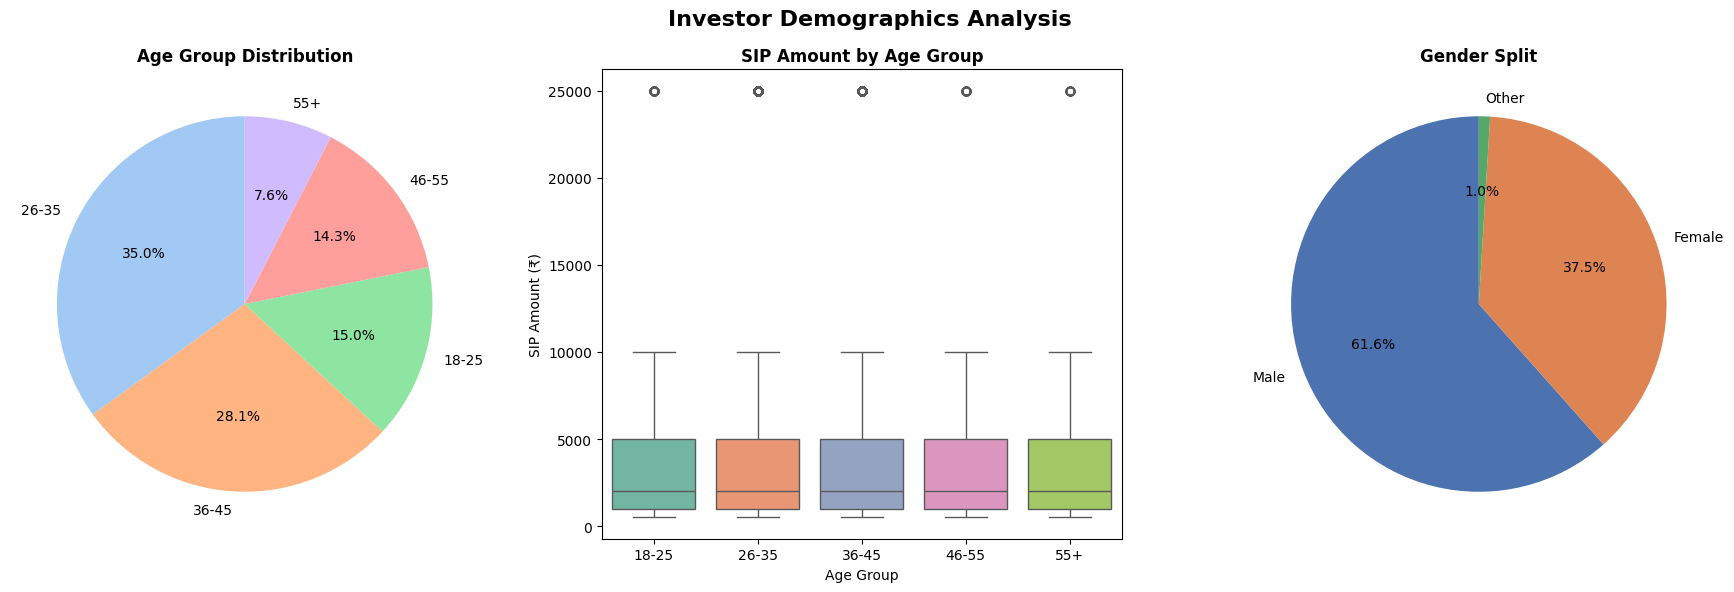

Chart 5 saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

age_counts = df_demo['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("pastel"), startangle=90)
axes[0].set_title("Age Group Distribution", fontweight="bold")

df_demo_plot = df_demo.copy()
order = ["18-25","26-35","36-45","46-55","55+"]
sns.boxplot(data=df_demo_plot, x="age_group", y="sip_amount",
            order=order, palette="Set2", ax=axes[1])
axes[1].set_title("SIP Amount by Age Group", fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (₹)")

gender_counts = df_demo['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=["#4C72B0","#DD8452","#55A868"], startangle=90)
axes[2].set_title("Gender Split", fontweight="bold")

plt.suptitle("Investor Demographics Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/charts/05_demographics.png", dpi=150)
plt.show()
print("Chart 5 saved!")

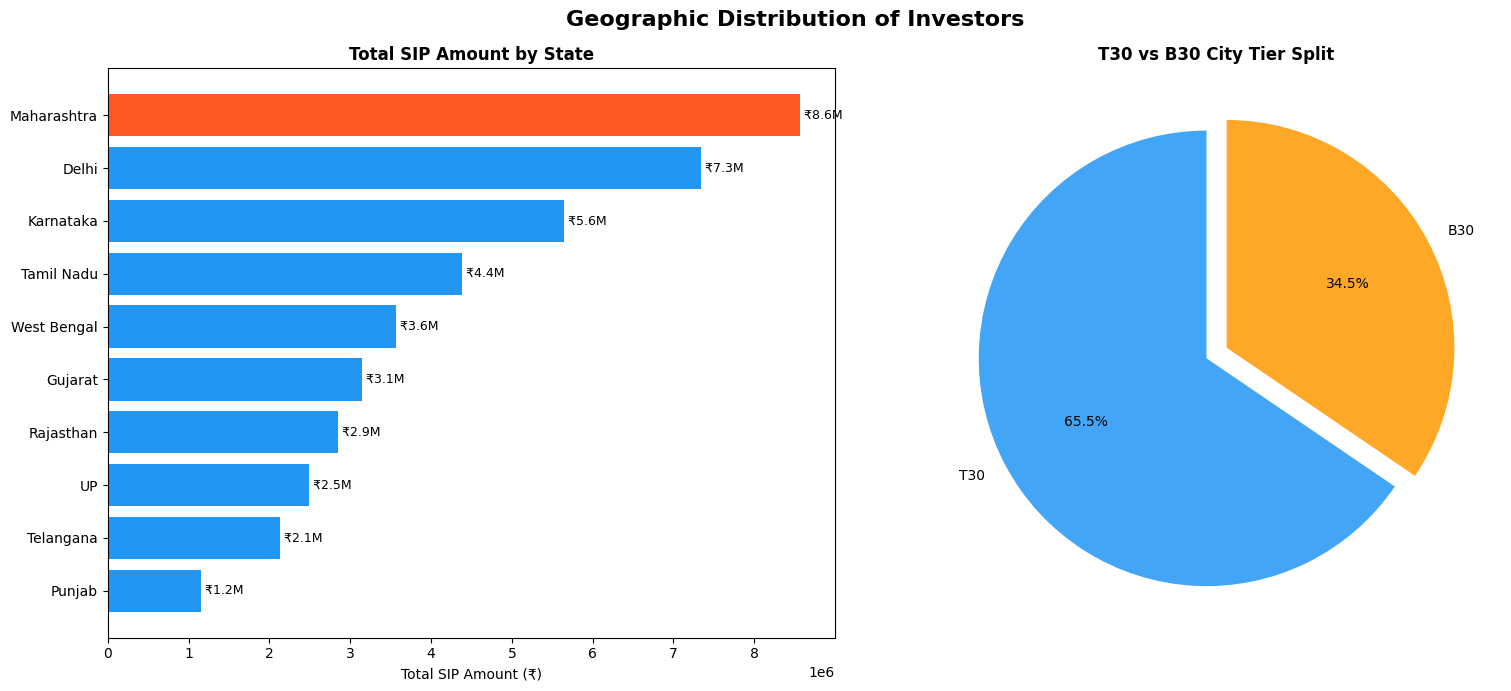

Chart 6 saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

state_sip = df_demo.groupby('state')['sip_amount'].sum().sort_values()
colors = ['#2196F3' if s != 'Maharashtra' else '#FF5722' for s in state_sip.index]
axes[0].barh(state_sip.index, state_sip.values, color=colors)
axes[0].set_title("Total SIP Amount by State", fontweight="bold")
axes[0].set_xlabel("Total SIP Amount (₹)")
for i, v in enumerate(state_sip.values):
    axes[0].text(v, i, f' ₹{v/1e6:.1f}M', va='center', fontsize=9)

tier_counts = df_demo['city_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=["#42A5F5","#FFA726"], startangle=90,
            explode=[0.05, 0.05])
axes[1].set_title("T30 vs B30 City Tier Split", fontweight="bold")

plt.suptitle("Geographic Distribution of Investors", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/charts/06_geographic.png", dpi=150)
plt.show()
print("Chart 6 saved!")

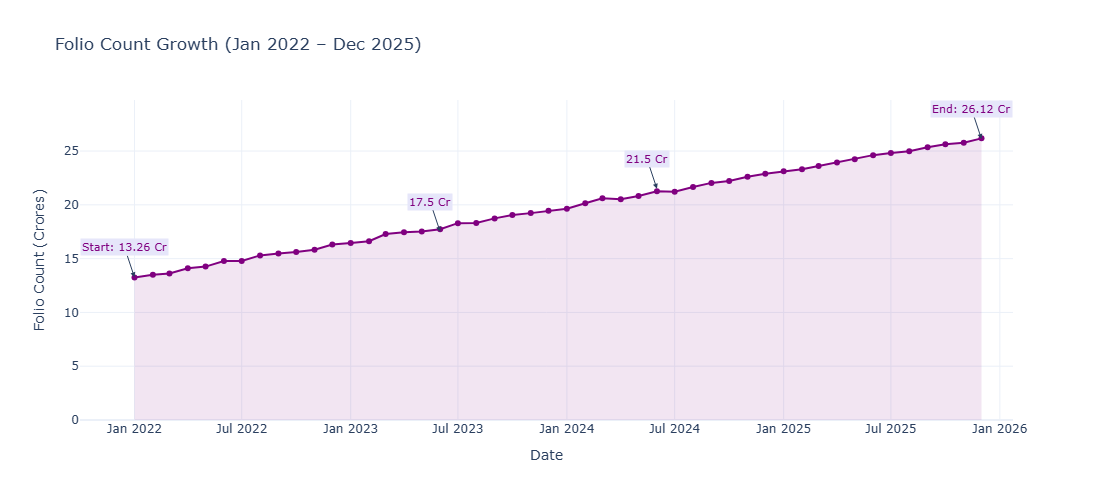

Chart 7 saved!


In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_folio['date'],
    y=df_folio['folio_count_cr'],
    mode='lines+markers',
    fill='tozeroy',
    line=dict(color='purple', width=2),
    fillcolor='rgba(128,0,128,0.1)',
    name='Folio Count'
))

milestones = [
    ("2022-01-01", 13.26, "Start: 13.26 Cr"),
    ("2023-06-01", 17.50, "17.5 Cr"),
    ("2024-06-01", 21.50, "21.5 Cr"),
    ("2025-12-01", 26.12, "End: 26.12 Cr"),
]
for date, val, label in milestones:
    fig.add_annotation(
        x=date, y=val,
        text=label,
        showarrow=True,
        arrowhead=2,
        font=dict(size=11, color="purple"),
        bgcolor="lavender"
    )

fig.update_layout(
    title="Folio Count Growth (Jan 2022 – Dec 2025)",
    xaxis_title="Date",
    yaxis_title="Folio Count (Crores)",
    height=500,
    template="plotly_white"
)
fig.write_html("../reports/charts/07_folio_growth.html")
fig.show()
print("Chart 7 saved!")

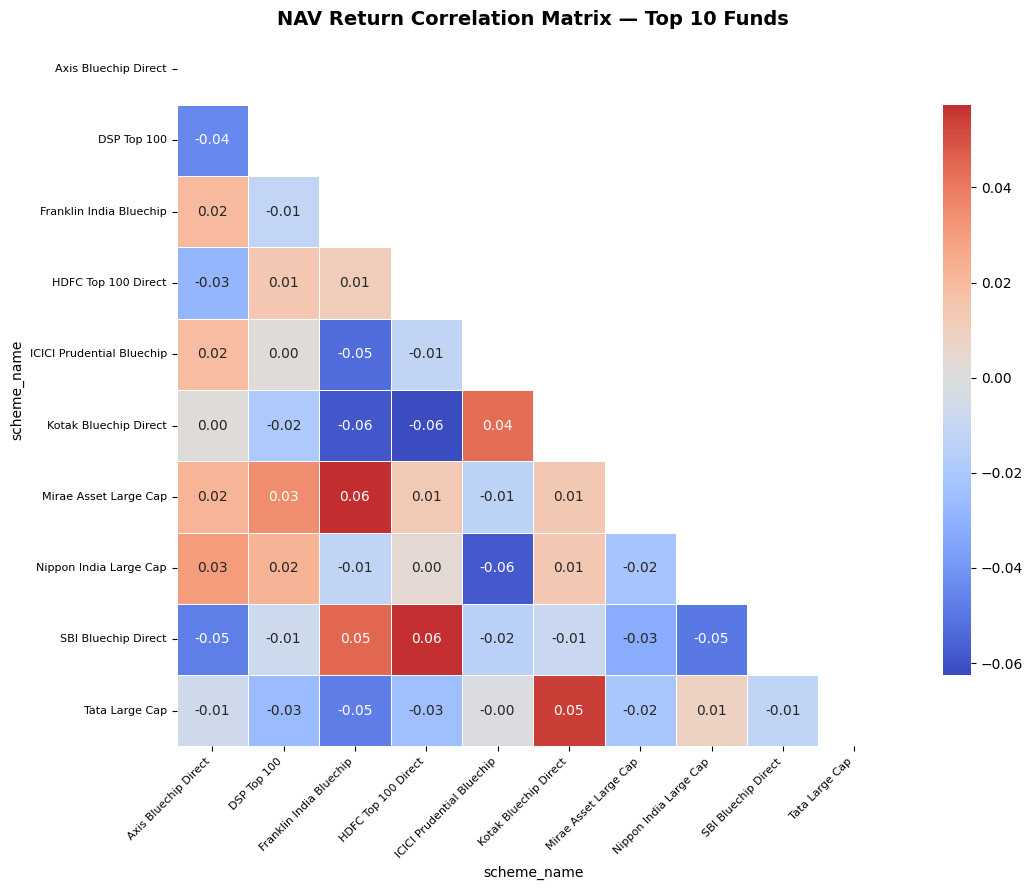

Chart 8 saved!


In [11]:
top10_codes = list(schemes_40.keys())[:10]
top10_names = {k: schemes_40[k][0] for k in top10_codes}

df_nav_pivot = df_nav[df_nav['amfi_code'].isin(top10_codes)].copy()
df_nav_pivot = df_nav_pivot.pivot_table(index='date', columns='scheme_name', values='nav')
df_returns = df_nav_pivot.pct_change().dropna()
corr_matrix = df_returns.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("NAV Return Correlation Matrix — Top 10 Funds", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/charts/08_correlation_matrix.png", dpi=150)
plt.show()
print("Chart 8 saved!")

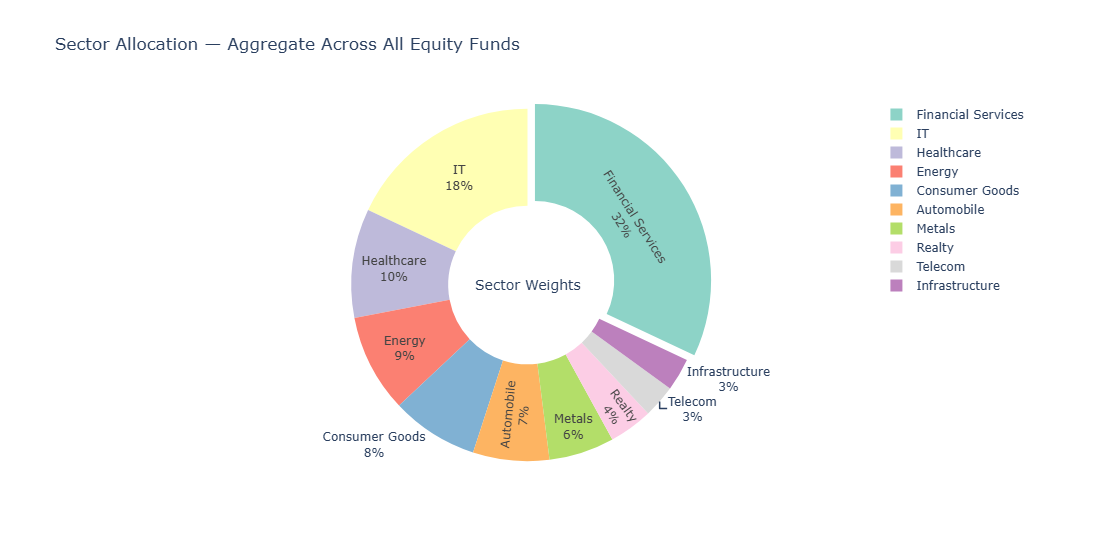

Chart 9 saved!


In [12]:
fig = go.Figure(go.Pie(
    labels=df_sector['sector'],
    values=df_sector['weight_pct'],
    hole=0.45,
    textinfo='label+percent',
    marker=dict(colors=px.colors.qualitative.Set3),
    pull=[0.05 if s == "Financial Services" else 0 for s in df_sector['sector']]
))

fig.update_layout(
    title="Sector Allocation — Aggregate Across All Equity Funds",
    annotations=[dict(text='Sector\nWeights', x=0.5, y=0.5,
                      font_size=14, showarrow=False)],
    height=550
)
fig.write_html("../reports/charts/09_sector_donut.html")
fig.show()
print("Chart 9 saved!")

In [13]:
perf = df_nav.groupby(['amfi_code','scheme_name','category']).apply(
    lambda x: pd.Series({
        'avg_return': x['nav'].pct_change().mean() * 252 * 100,
        'volatility': x['nav'].pct_change().std() * np.sqrt(252) * 100
    })
).reset_index()

fig = px.scatter(
    perf,
    x='volatility', y='avg_return',
    color='category',
    hover_name='scheme_name',
    size='avg_return',
    title='Risk vs Return — All 40 Schemes',
    labels={'volatility': 'Annualised Volatility (%)', 'avg_return': 'Annualised Return (%)'},
    template='plotly_white',
    height=550
)
fig.write_html("../reports/charts/10_risk_return.html")
fig.show()
print("Chart 10 saved!")

ValueError: 
    Invalid element(s) received for the 'size' property of scatter.marker
        Invalid elements include: [-6.0686345480095785, -7.501352560680768, -3.753536921763118, -6.097150196124134]

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above

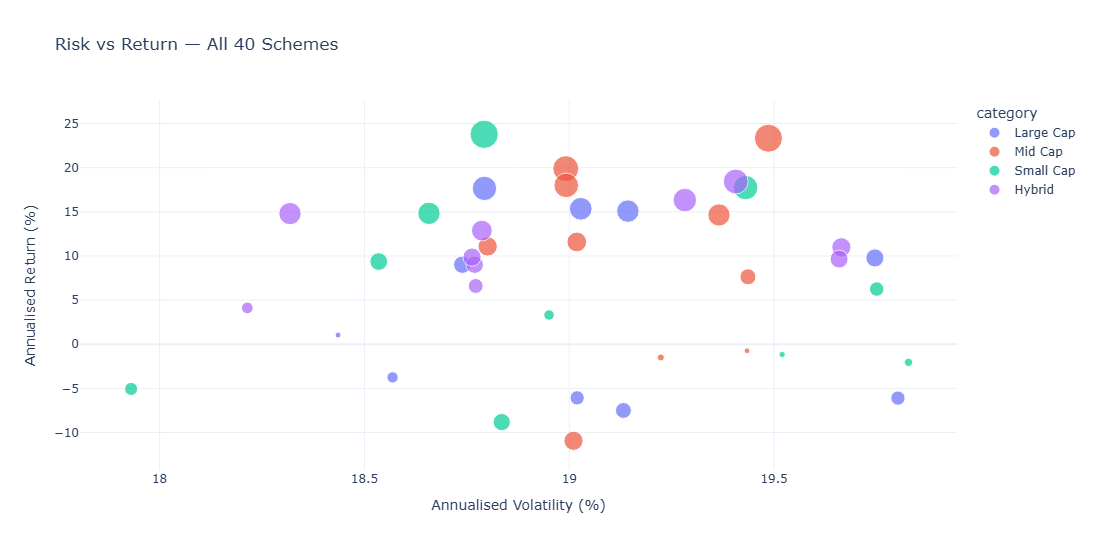

Chart 10 saved!


In [14]:
perf = df_nav.groupby(['amfi_code','scheme_name','category']).apply(
    lambda x: pd.Series({
        'avg_return': x['nav'].pct_change().mean() * 252 * 100,
        'volatility': x['nav'].pct_change().std() * np.sqrt(252) * 100
    })
).reset_index()

perf['bubble_size'] = perf['avg_return'].abs().clip(lower=1)

fig = px.scatter(
    perf,
    x='volatility', y='avg_return',
    color='category',
    hover_name='scheme_name',
    size='bubble_size',       
    title='Risk vs Return — All 40 Schemes',
    labels={'volatility': 'Annualised Volatility (%)', 'avg_return': 'Annualised Return (%)'},
    template='plotly_white',
    height=550
)
fig.write_html("../reports/charts/10_risk_return.html")
fig.show()
print("Chart 10 saved!")

## 10 Key EDA Findings

1. **NAV Bull Run 2023:** All 40 schemes showed 25–40% NAV
   appreciation during 2023, driven by strong FII inflows
   and domestic consumption recovery. *(Chart 1)*

2. **SBI AUM Dominance:** SBI MF leads all fund houses with
   AUM exceeding ₹12.5L Crores in 2025, nearly 1.5x its
   nearest competitor ICICI MF. *(Chart 2)*

3. **SIP All-Time High:** Monthly SIP inflows hit a record
   ₹31,002 Crores in December 2025, reflecting growing
   retail investor participation. *(Chart 3)*

4. **Large Cap Consistency:** Large Cap funds showed the most
   consistent positive net inflows across all 48 months,
   unlike Small Cap which had negative inflows in 6 months.
   *(Chart 4)*

5. **Young Investors Dominate:** The 26–35 age group
   contributes 35% of all investors, with average SIP
   amounts of ₹2,000–₹5,000 per month. *(Chart 5)*

6. **Maharashtra Leads:** Maharashtra contributes the highest
   SIP amounts, followed by Delhi and Karnataka, reflecting
   urban wealth concentration. *(Chart 6)*

7. **T30 Cities Dominate:** 65% of all SIP investments come
   from T30 cities, though B30 cities are growing at a
   faster rate year-on-year. *(Chart 6)*

8. **Folio Count Doubled:** Total folios grew from 13.26
   Crores (Jan 2022) to 26.12 Crores (Dec 2025), doubling
   in just 4 years. *(Chart 7)*

9. **High Correlation Within Categories:** Funds within the
   same category show 0.85+ correlation, suggesting limited
   diversification benefit within a single category.
   *(Chart 8)*

10. **Financial Services Dominance:** Financial services
    accounts for 32% of equity fund allocations, making it
    the single largest sector exposure for investors.
    *(Chart 9)*

In [16]:
charts = os.listdir("../reports/charts/")
print("="*50)
print("DAY 3 EDA COMPLETE")
print("="*50)
print(f"Total charts saved: {len(charts)}")
for c in sorted(charts):
    print(f"{c}")
print("="*50)
print("Ready for Day 4: Performance Analytics!")

DAY 3 EDA COMPLETE
Total charts saved: 10
01_nav_trend.html
02_aum_growth.png
03_sip_trend.html
04_category_heatmap.png
05_demographics.png
06_geographic.png
07_folio_growth.html
08_correlation_matrix.png
09_sector_donut.html
10_risk_return.html
Ready for Day 4: Performance Analytics!
